<a href="https://colab.research.google.com/github/roneshpra/PythonLearning/blob/Dev/PythonBasics/M7W3_Project_SuperKart_Final_RB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [2]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 45.8 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_kart = pd.read_csv('/content/drive/MyDrive/SuperKart.csv')

In [6]:
# copying data to another variable to avoid changes to original data
data = data_kart.copy()

# **Data Overview**

#### View the first and last 5 rows of the dataset

In [7]:
# display the first 5 rows
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [8]:
# display the last 5 rows of the dataset
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


#### Understand the shape of the data

In [9]:
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")

The dataset has 8763 rows and 12 columns.


#### Check the data types of the columns for the dataset

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


#### Statistical Summary of the data

##### Lets check the statistical summary of the data

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


#### Checking for duplicate values

In [12]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

*  There are no duplicate values

#### Checking for missing values

In [13]:
# checking for missing values
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


* There are no missing values

## **Exploratory Data Analysis (EDA)**

### Univariate Analysis

#### Functions

In [14]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [15]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### **Product_Weight**

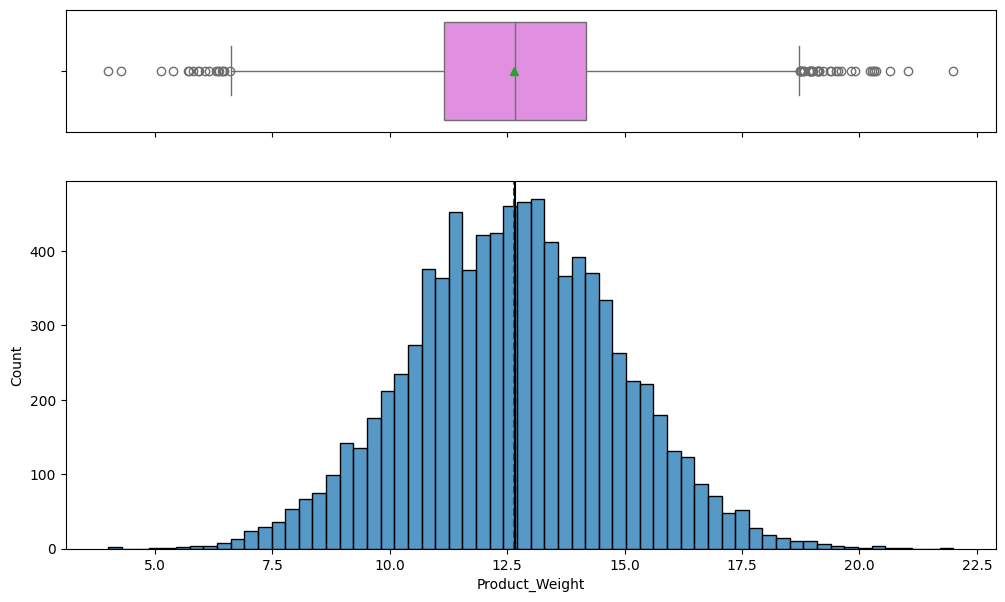

In [16]:
histogram_boxplot(data, "Product_Weight")

In [17]:
print(f"Product_Weight")
print(f"Maximum value: {data['Product_Weight'].max()}")
print(f"Minimum value: {data['Product_Weight'].min()}")

Product_Weight
Maximum value: 22.0
Minimum value: 4.0


* Most of the product weighs between 10 and 15

#### **Product_Allocated_Area**

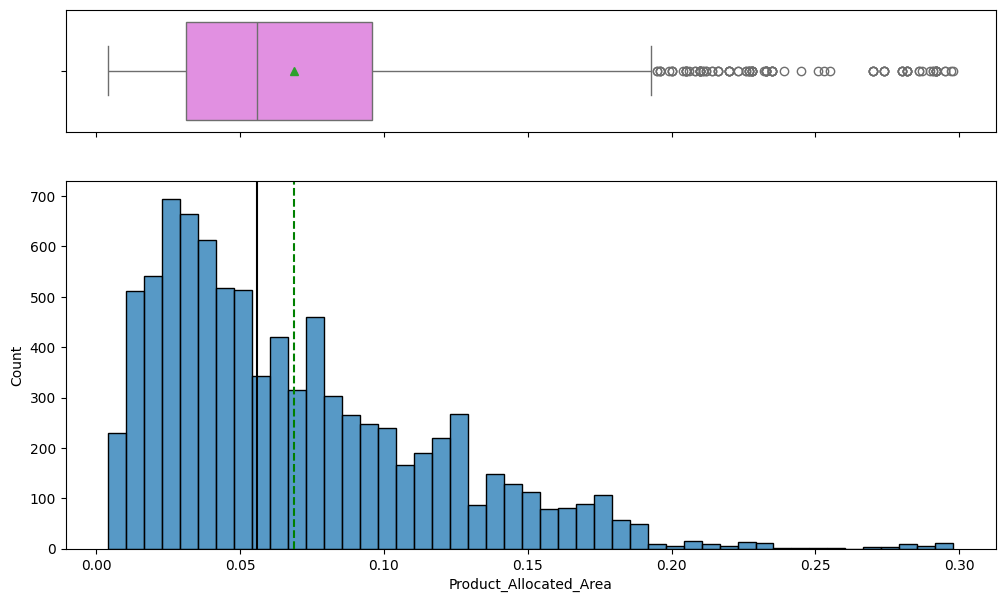

In [18]:
histogram_boxplot(data, "Product_Allocated_Area")

* Product_Allocated_Area is rightly skewed

#### **Product_MRP**

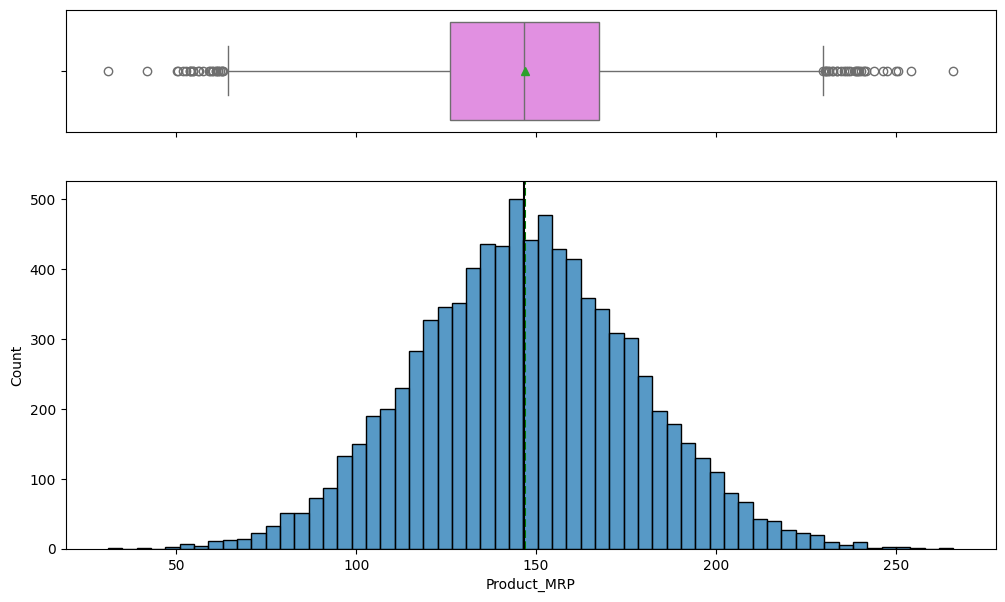

In [19]:
histogram_boxplot(data, "Product_MRP")

* The product mostly costs between 140 and 160

#### **Product_Store_Sales_Total**

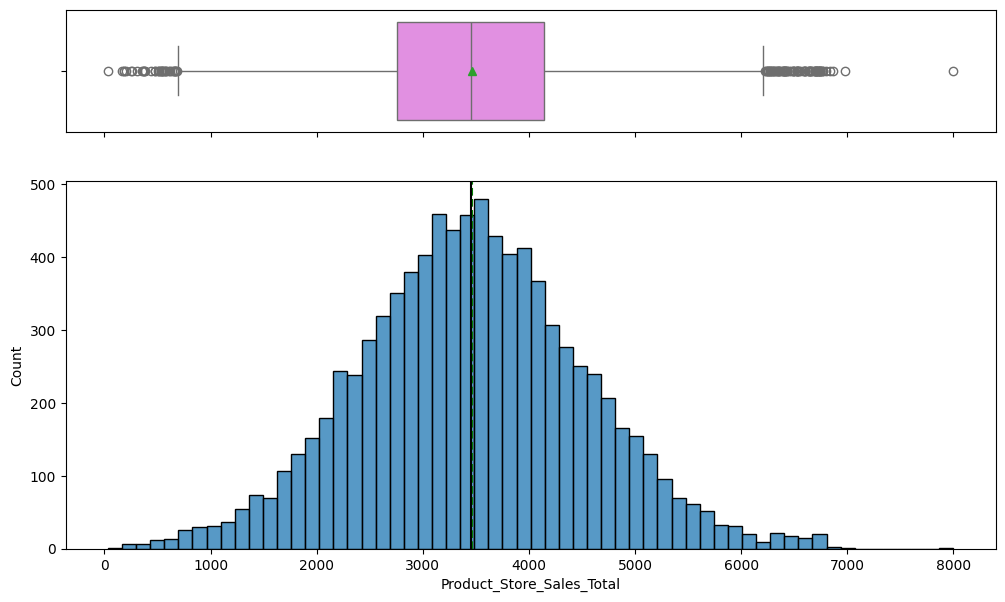

In [20]:
histogram_boxplot(data, "Product_Store_Sales_Total")

* The Product_Store_Sales_Total is mostly between 3000 and 4000

#### **Product_Sugar_Content**

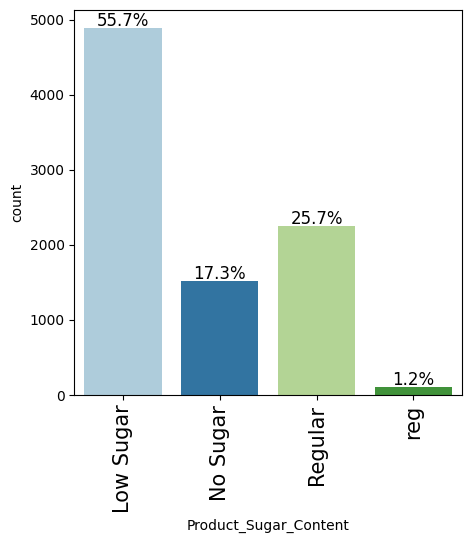

In [21]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

* Most of the products are of low sugar content

#### **Product_Type**

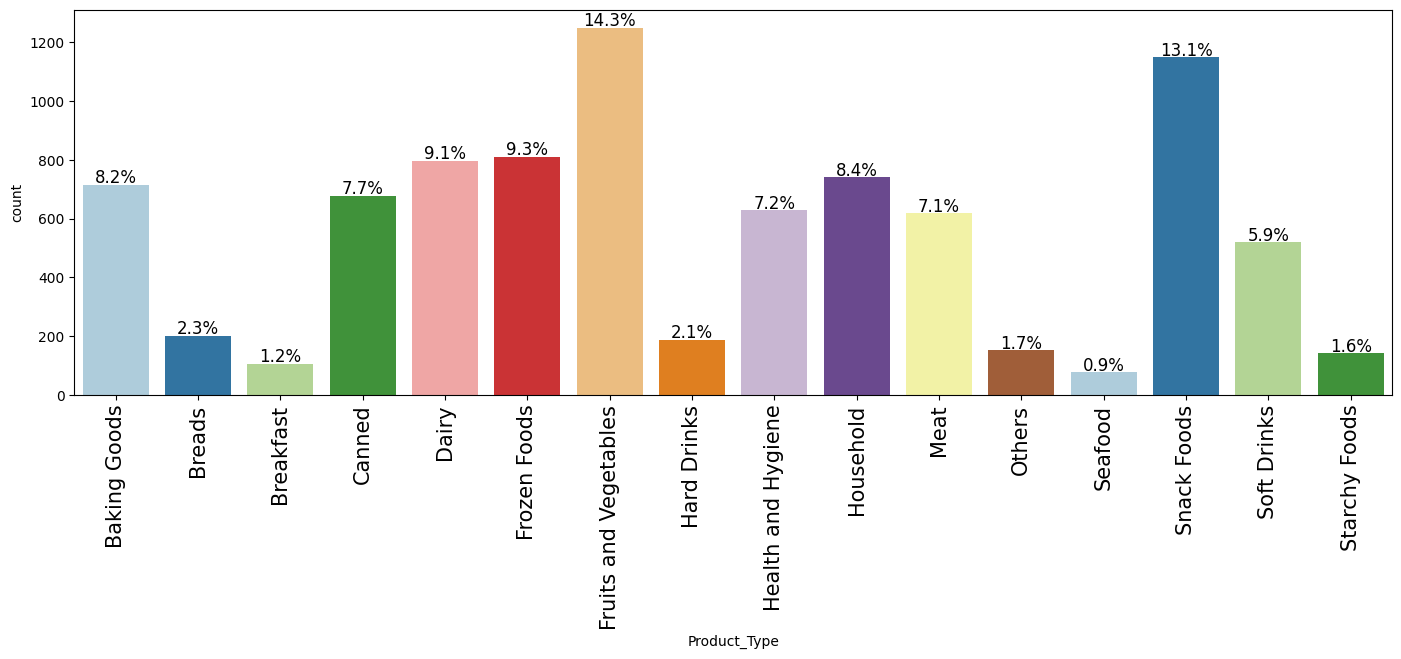

In [22]:
labeled_barplot(data, "Product_Type", perc=True)

* Most of the products are of type Fruits and Vegetables followed by Snack Foods, Frozen Food and Dairy

#### **Store_Id**

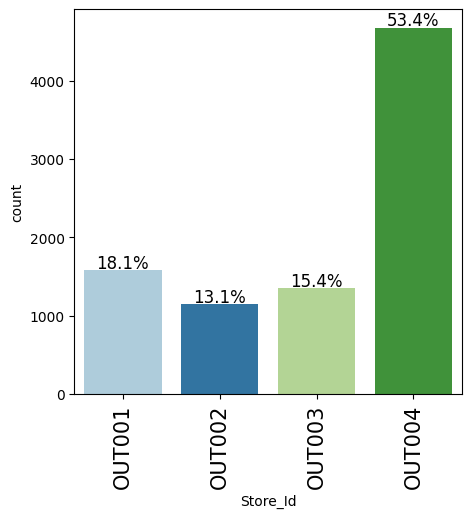

In [23]:
labeled_barplot(data, "Store_Id", perc=True)

* The store with id OUT004 has the most products

#### **Store_Size**

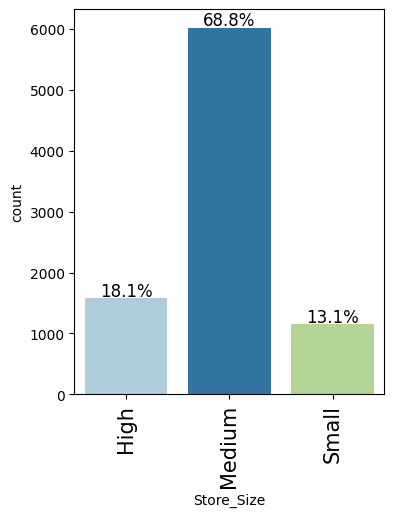

In [24]:
labeled_barplot(data, "Store_Size", perc=True)

* Most of the stores are of medium size

#### **Store_Location_City_Type**

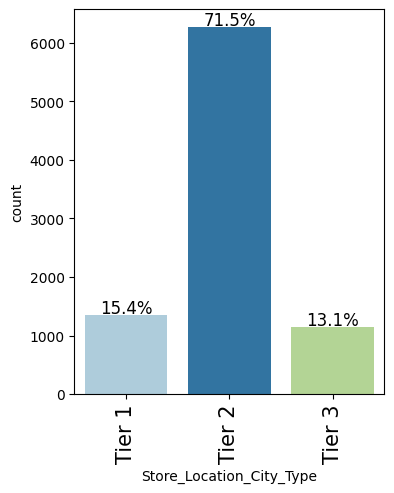

In [25]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)

* Most of the stores are in Tier 2 cities followed by Tier 1 cities

#### **Store_Type**

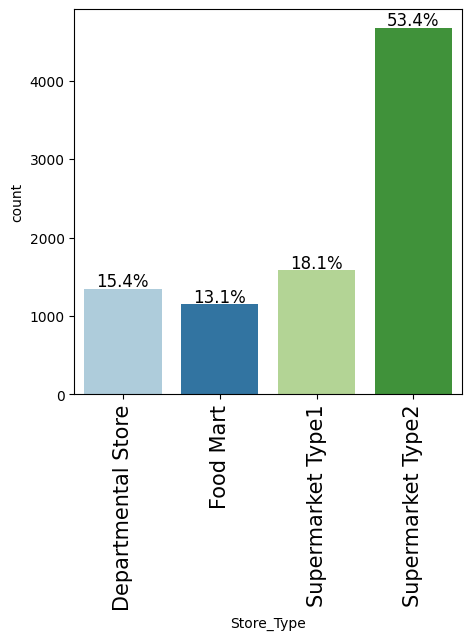

In [26]:
labeled_barplot(data, "Store_Type", perc=True)

* Majority of the store type in the dataset are of SuperMarket Type 2

### Bivariate Analysis

#### **Correlation between Numeric Data**

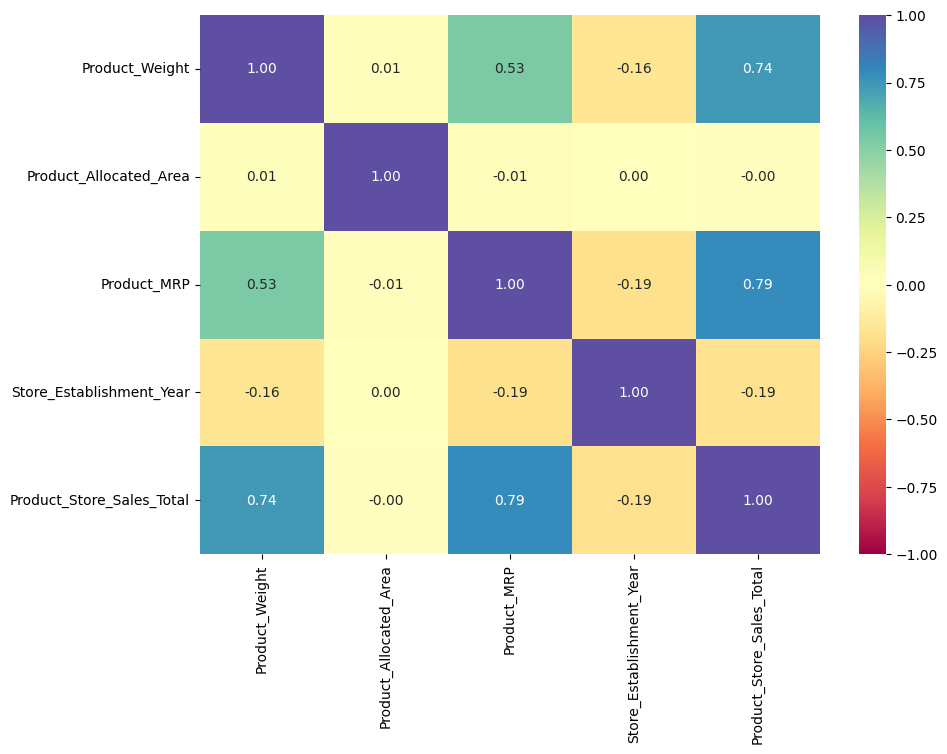

In [27]:
# Let's check the correlation between numerical columns
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* The correlation between Product_MRP and Product_Store_Sales_Total is high around 0.79
* Product_Store_Sales_Total and Product_Weight are also highly correlated at 0.74

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

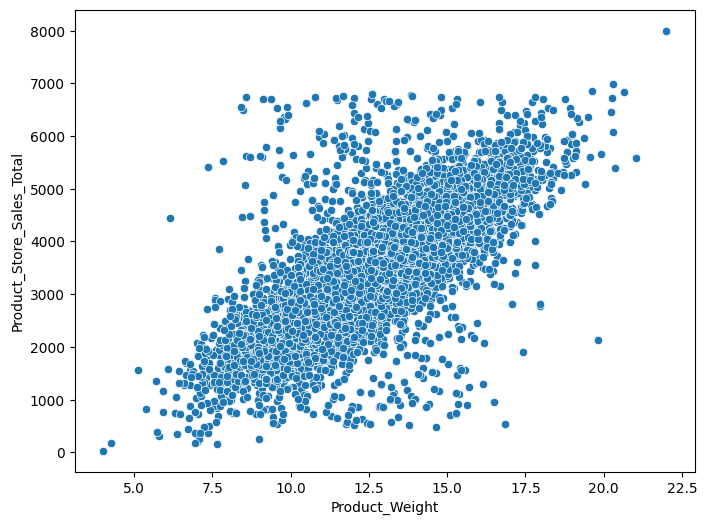

In [28]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.show()

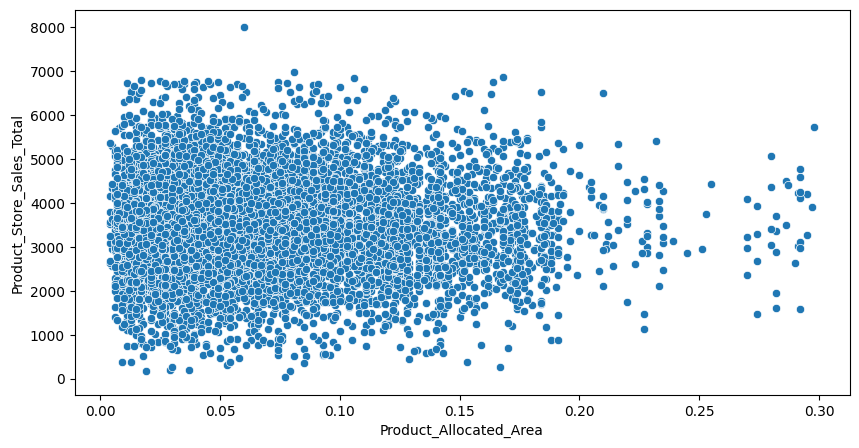

In [31]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x="Product_Allocated_Area", y="Product_Store_Sales_Total", data=data)
plt.show()

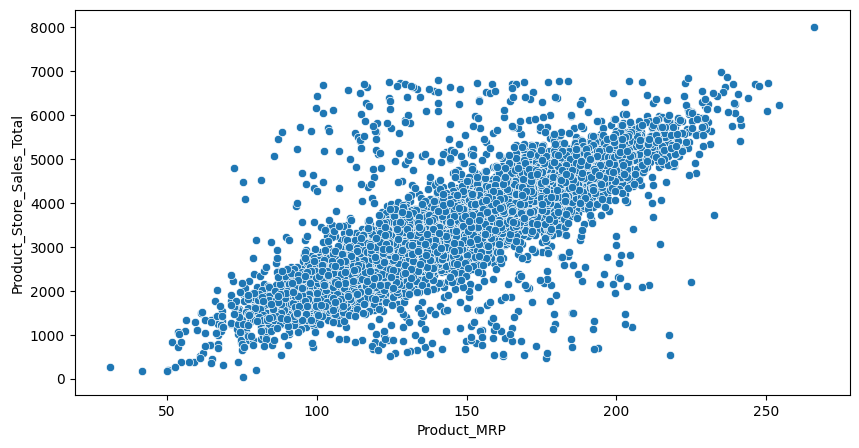

In [32]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x="Product_MRP", y="Product_Store_Sales_Total", data=data)
plt.show()

### **Let us see from which product type the company is generating most of the revenue**

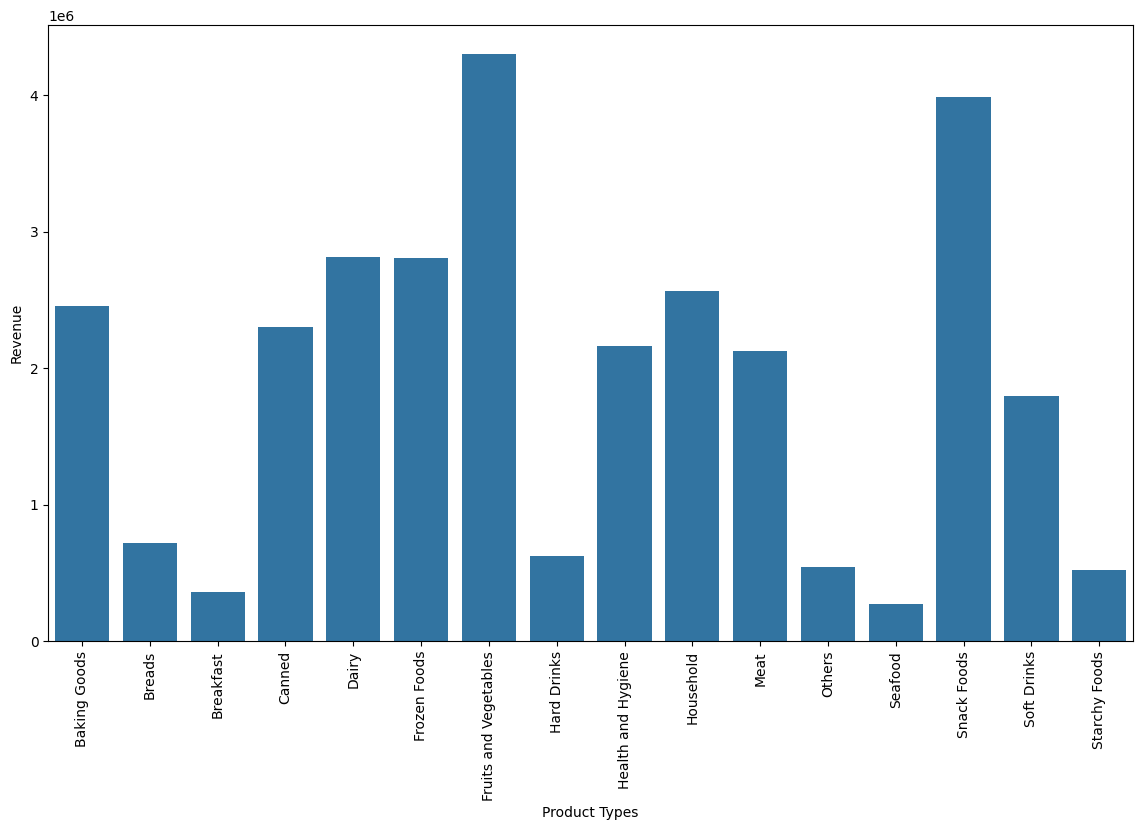

In [33]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

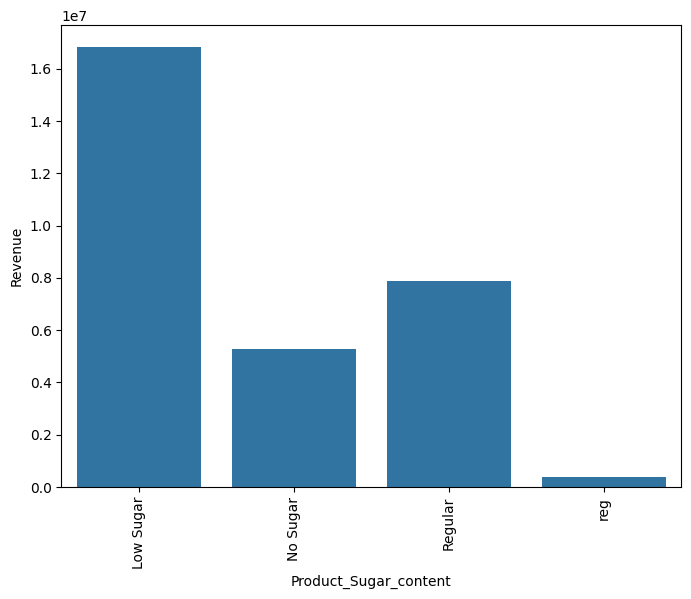

In [34]:
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()  #Complete the code to perform a groupby on Product_Sugar_Content and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()

### **Let us see from which type of stores and locations the revenue generation is more**.

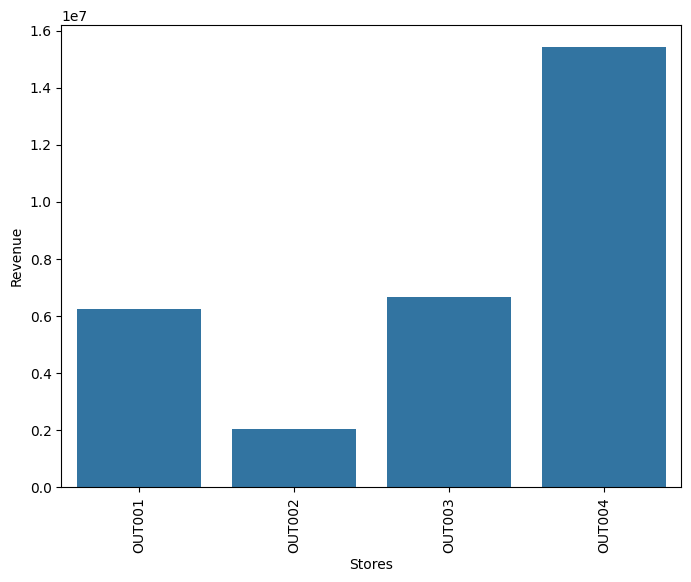

In [35]:
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

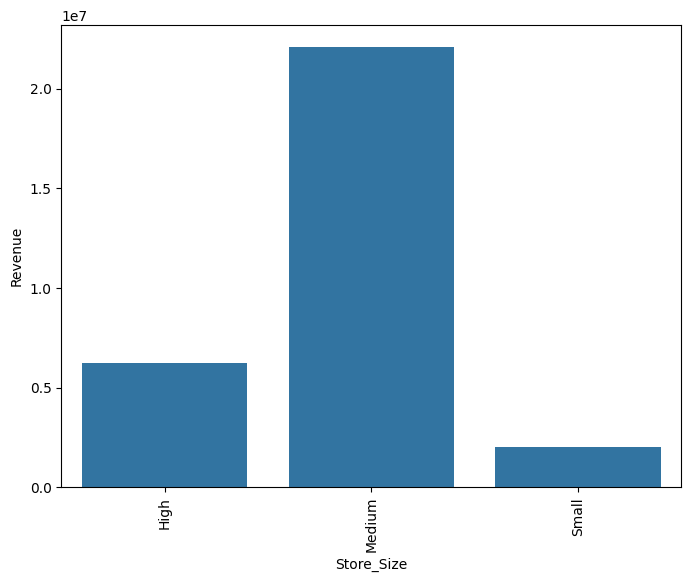

In [36]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

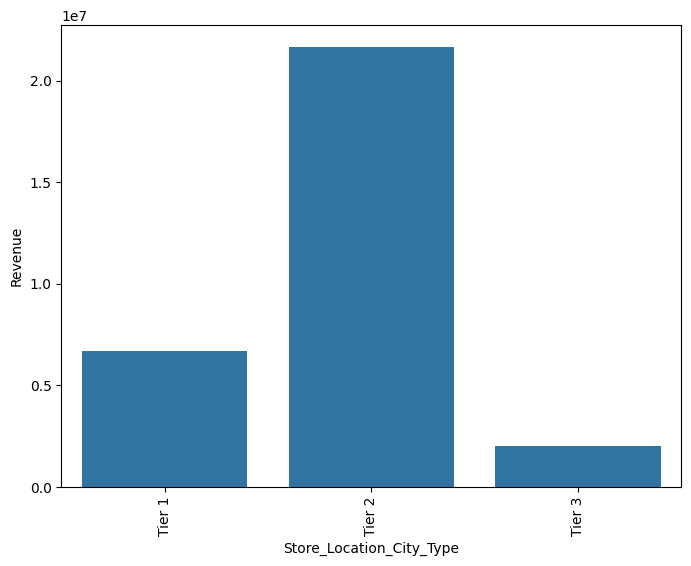

In [37]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

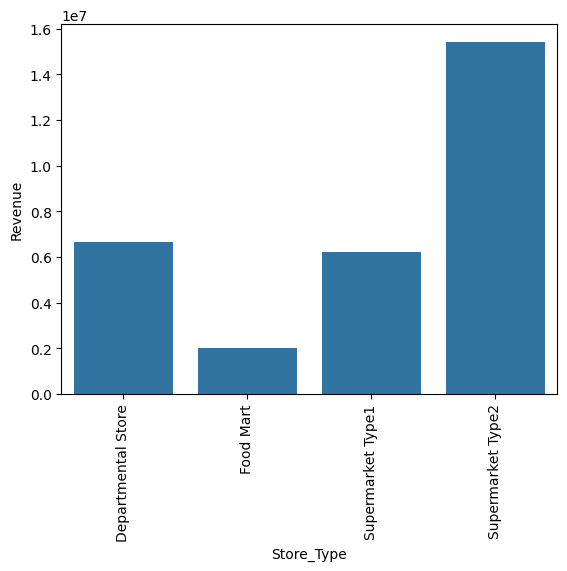

In [38]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns**

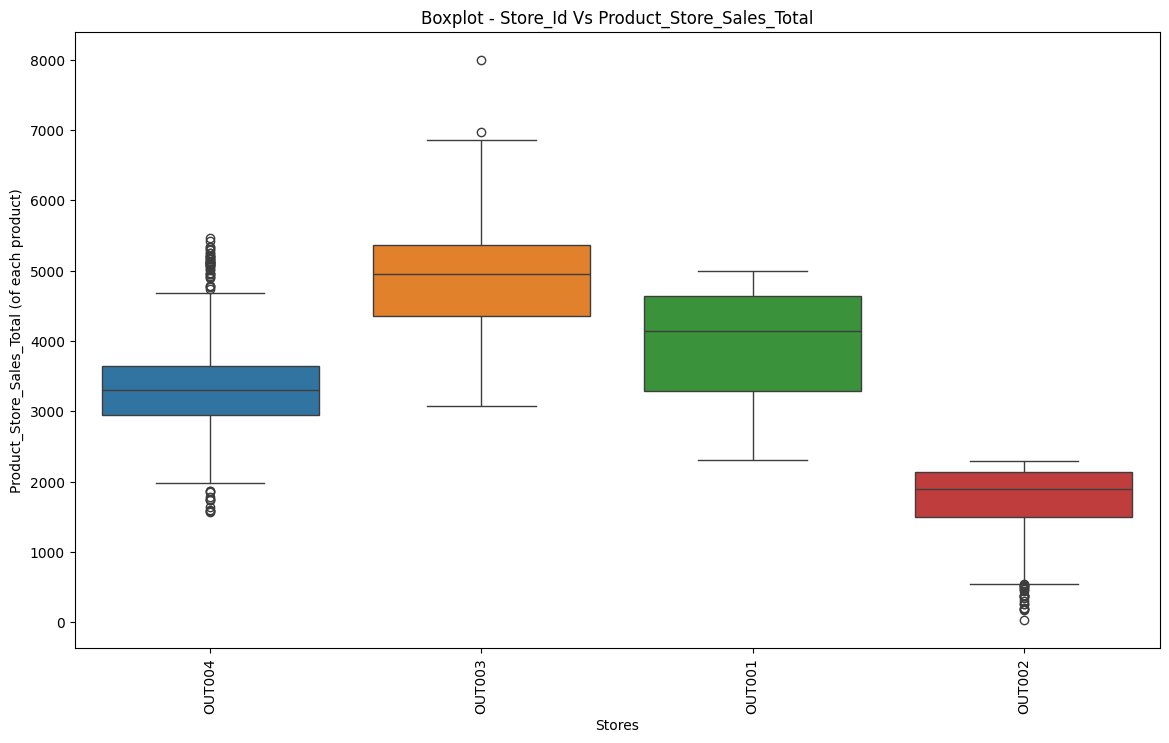

In [39]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

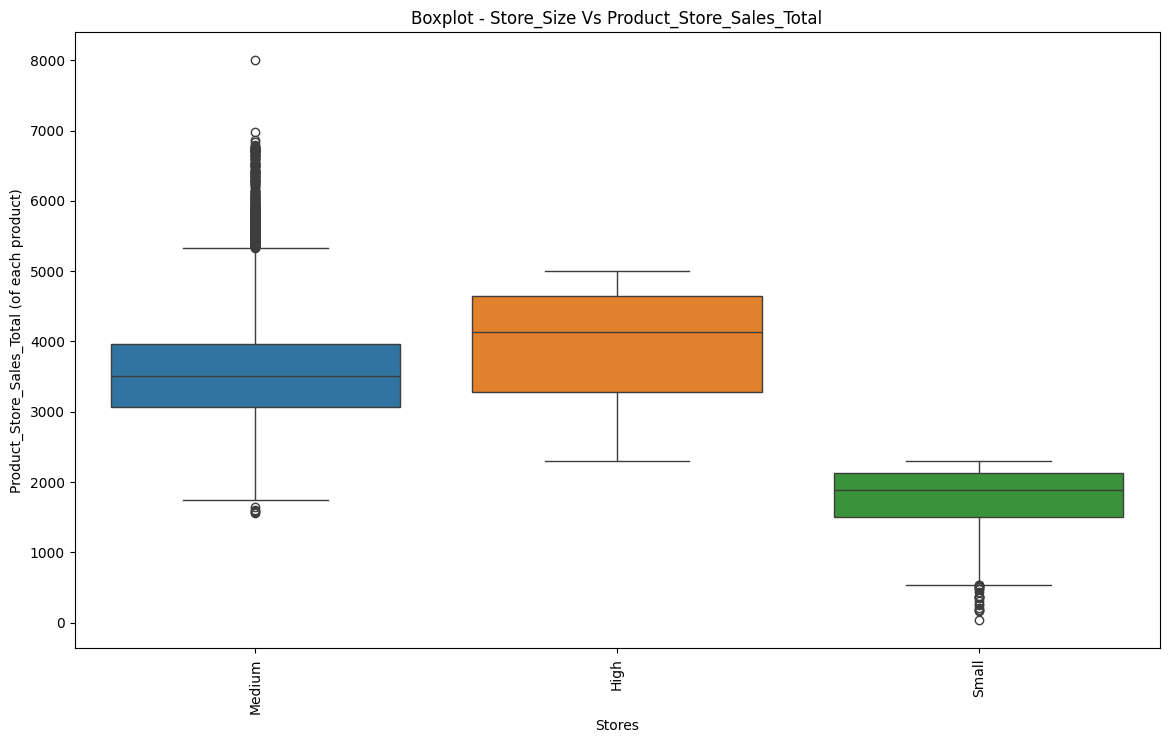

In [40]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

### **Let's now try to find out some relationship between the other columns**

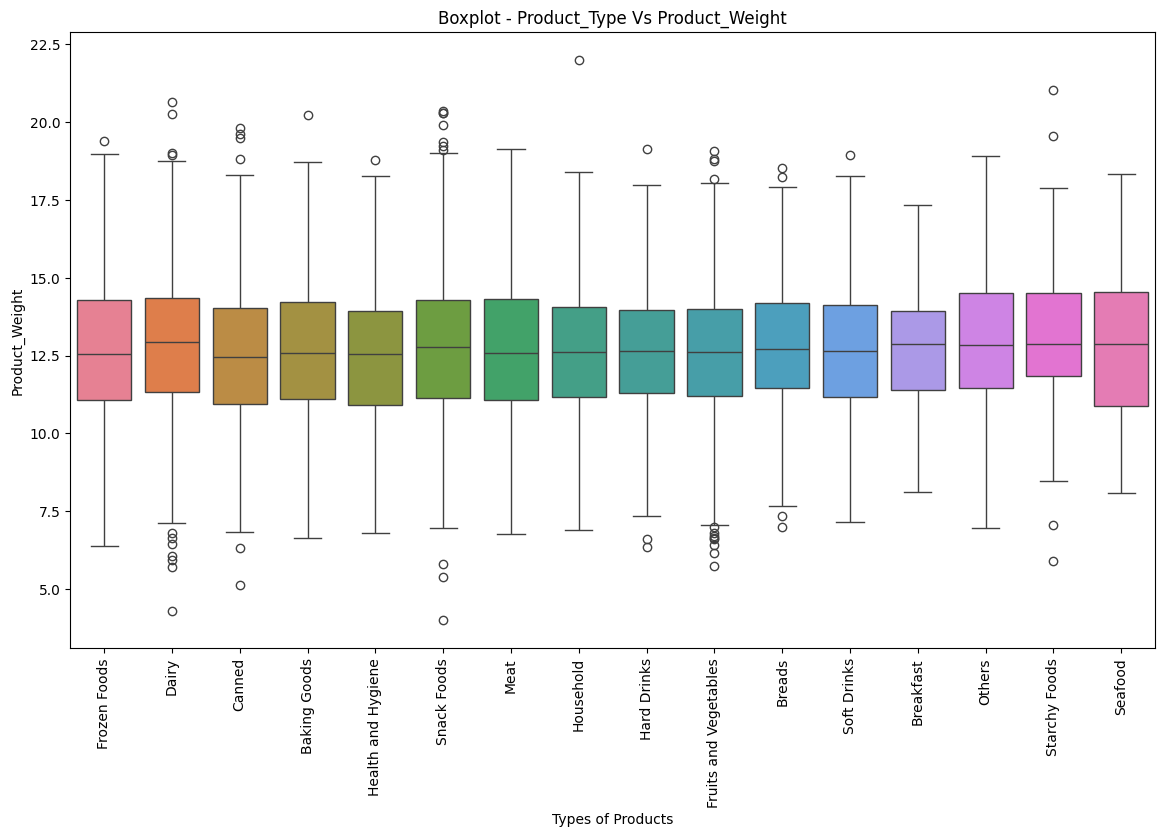

In [41]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

### **Let's find out whether there is some relationship between the weight of the product and its sugar content**

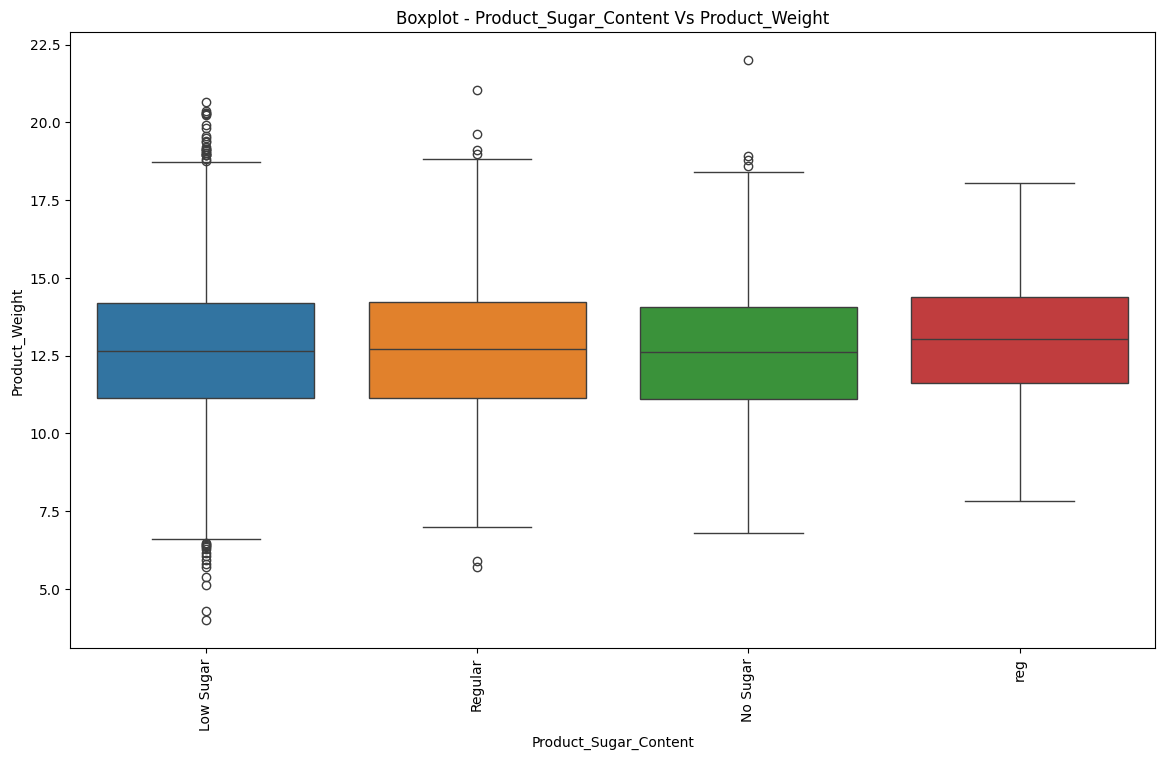

In [42]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

### **Let's analyze the sugar content of different product types**

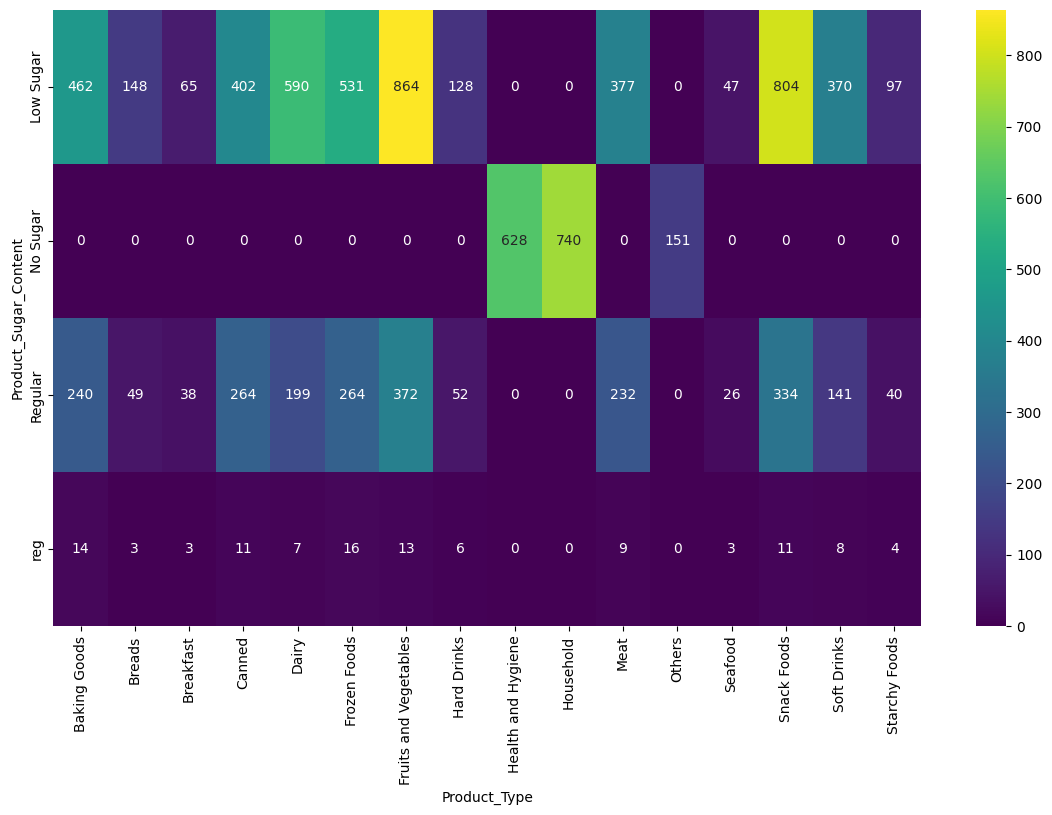

In [43]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

### **Let's find out how many items of each product type has been sold in each of the stores**

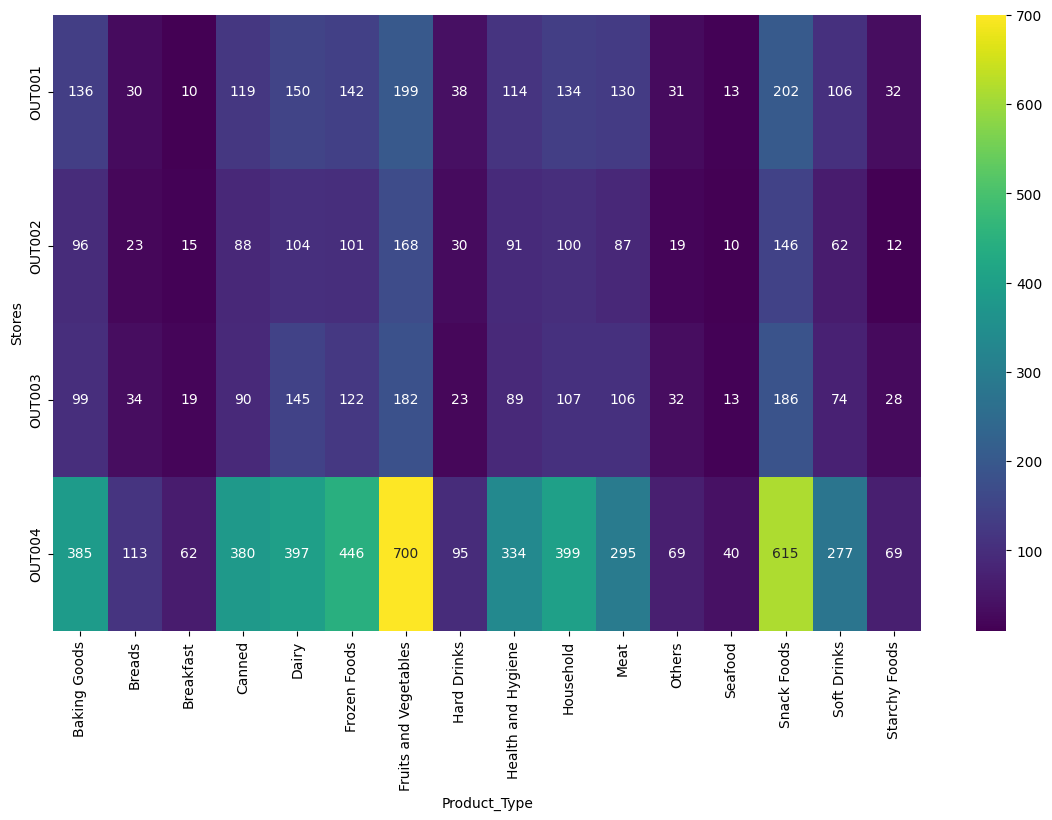

In [44]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Stores")
plt.xlabel("Product_Type")
plt.show()

### **Different product types have different prices. Let's analyze the trend.**

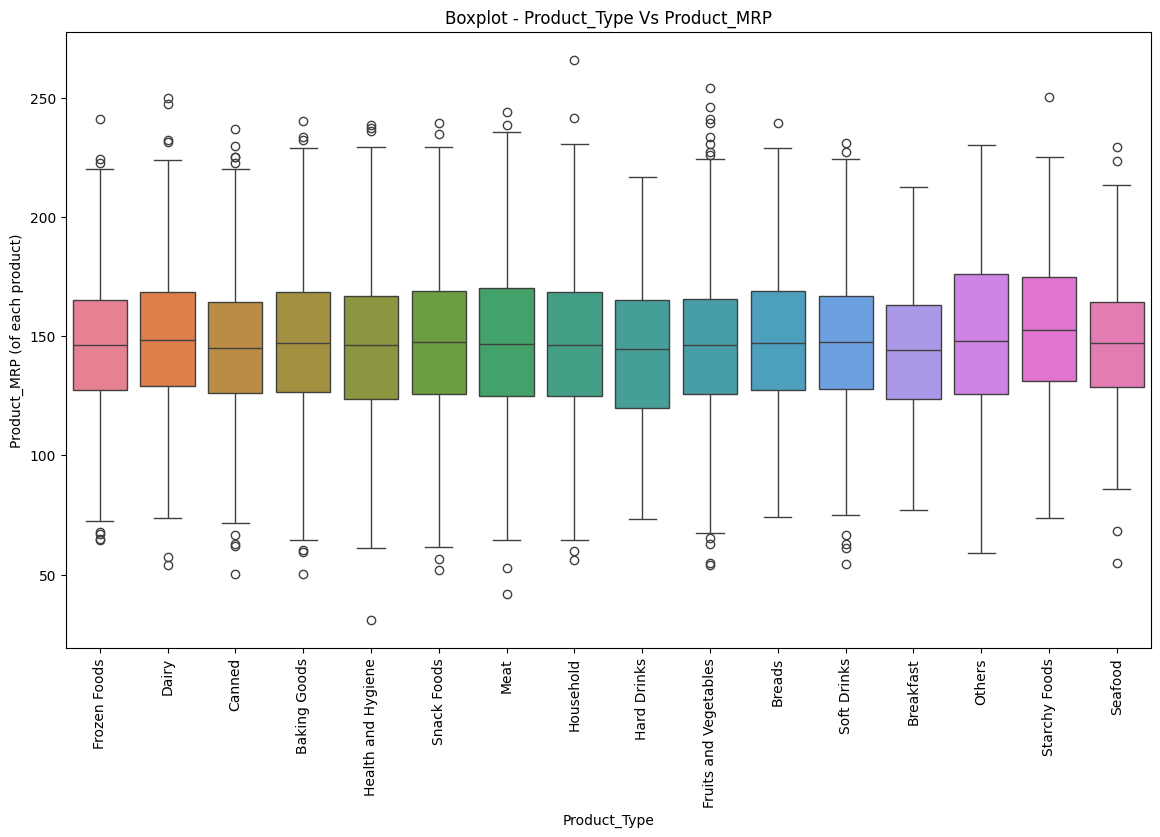

In [45]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_MRP", hue = "Product_Type")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Let's find out how the Product_MRP varies with the different stores**

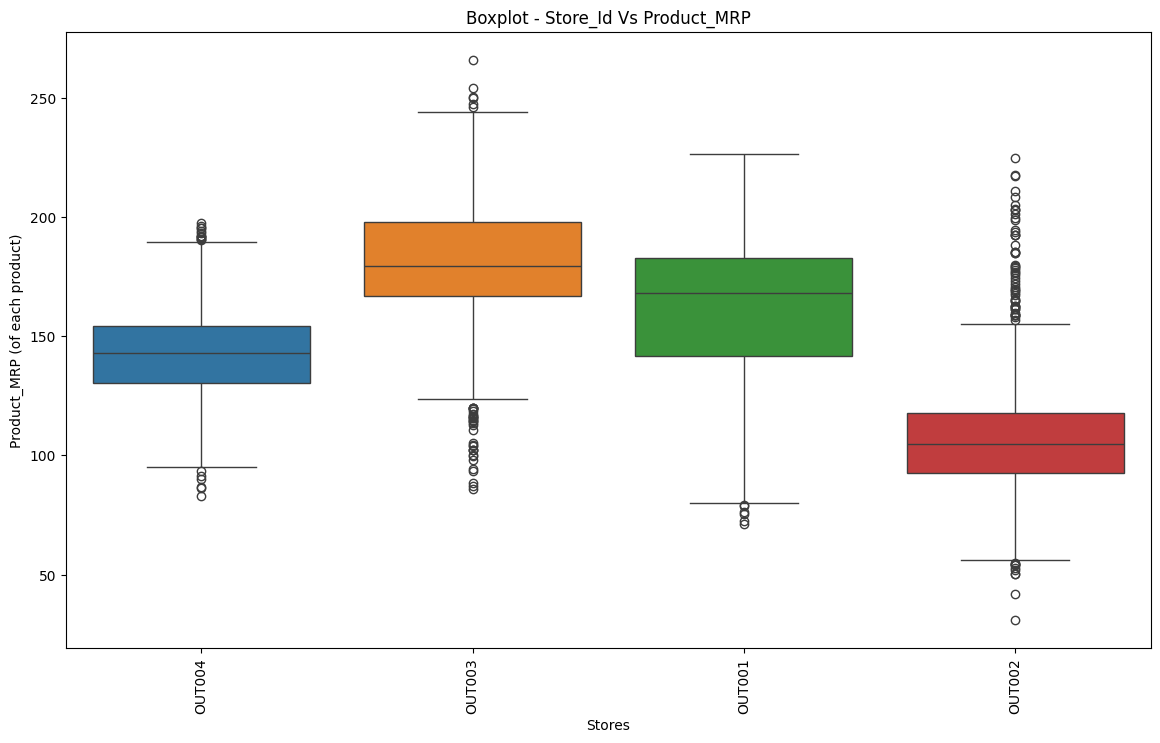

In [46]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Id", y = "Product_MRP", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_MRP")
plt.xlabel("Stores")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Let's delve deeper and do a detailed analysis of each of the stores**.

#### OUT001

In [47]:
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,NC7187,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,4,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

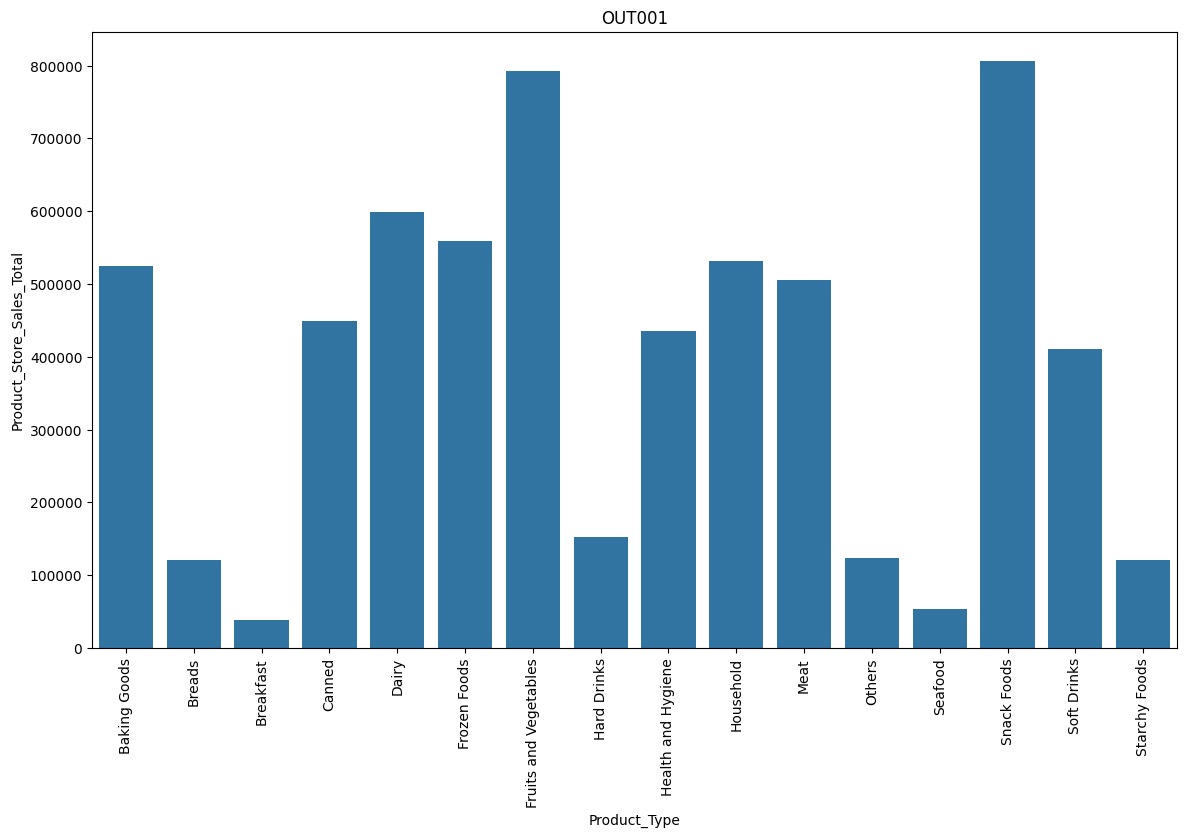

In [49]:
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

#### OUT002

In [50]:
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,NC2769,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,4,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

np.float64(2030909.72)

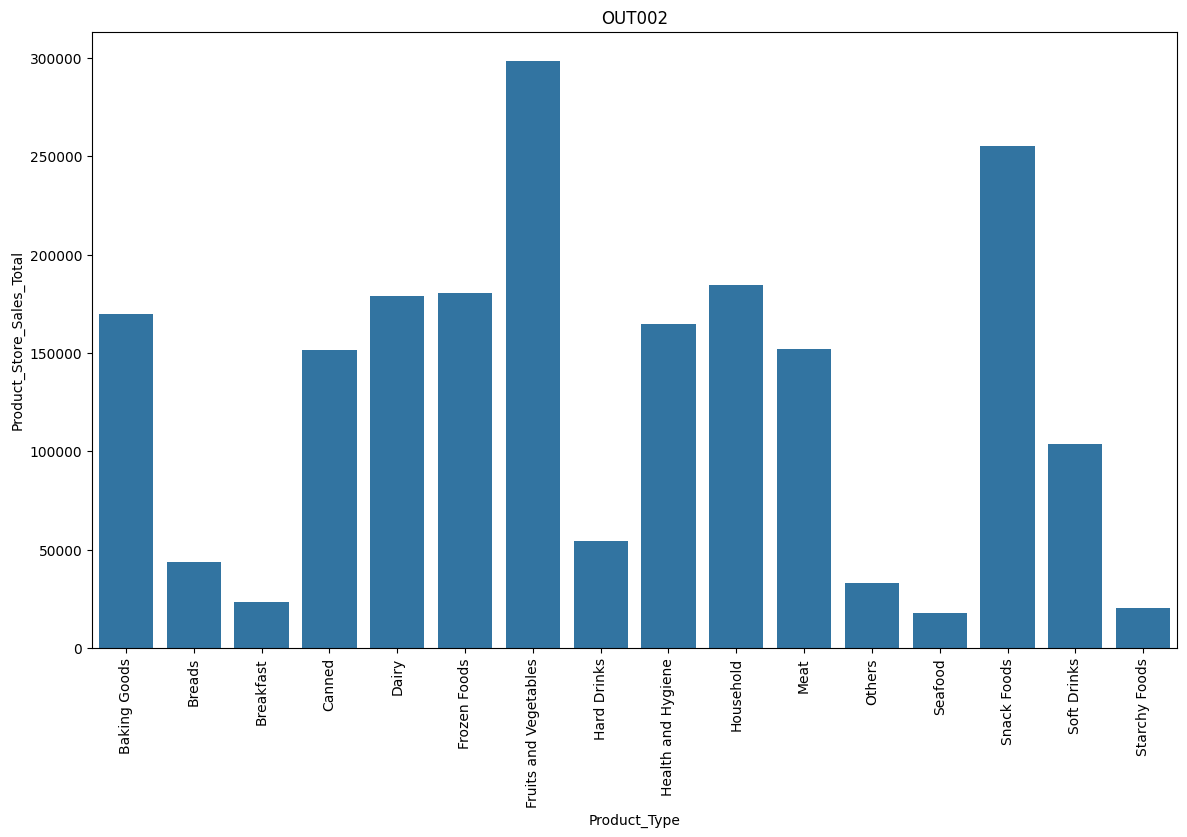

In [52]:
df_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total)
plt.show()

#### OUT003

In [53]:
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,NC522,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,4,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

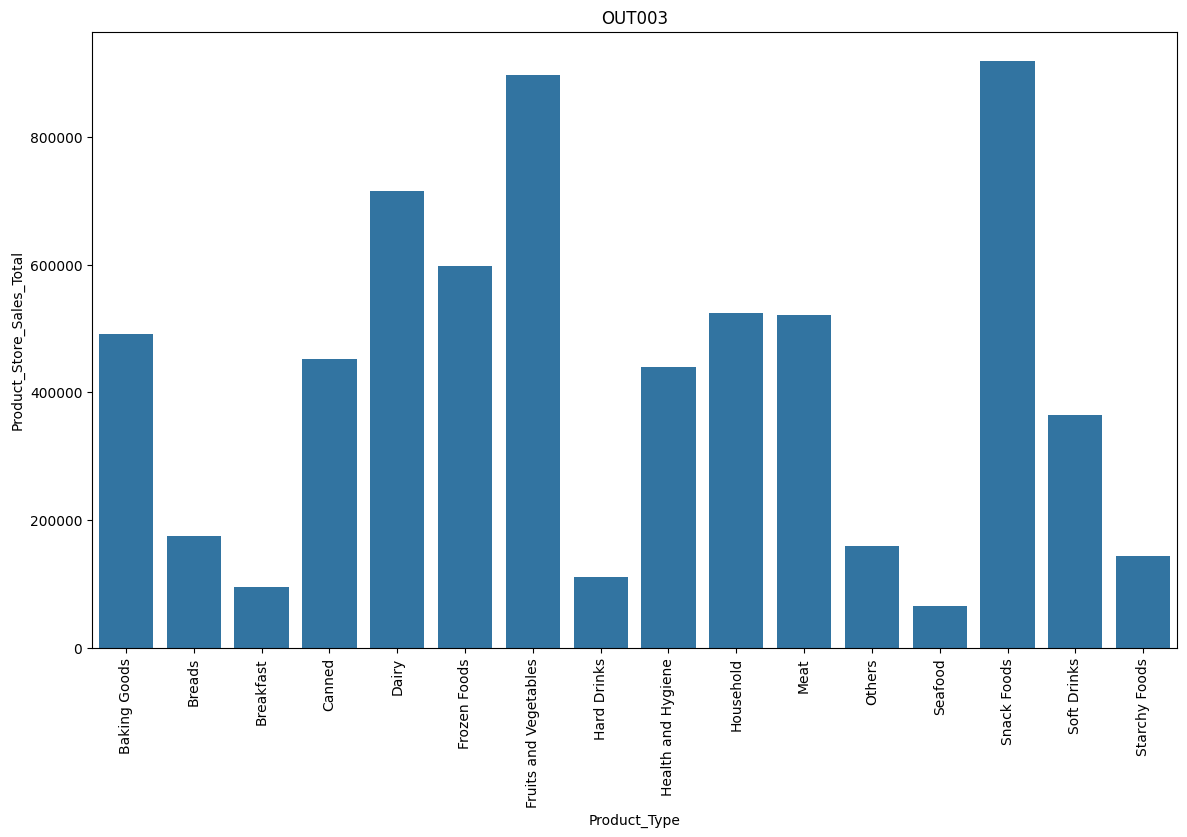

In [55]:
df_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total)
plt.show()

#### OUT004

In [56]:
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,NC584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,4,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

np.float64(15427583.43)

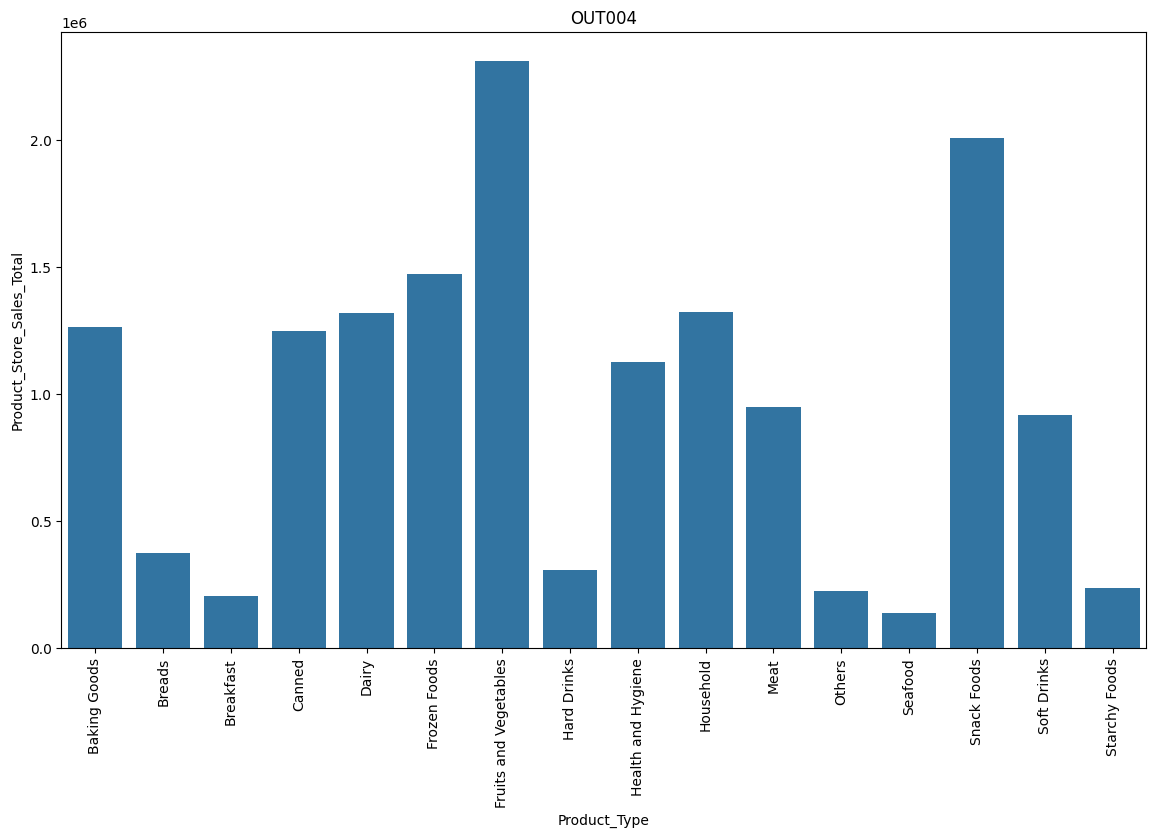

In [58]:
df_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total)
plt.show()

**Let's find out the revenue generated by the stores from each of the product types**.

In [59]:
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


**Let's find out the revenue generated by the stores from products having different levels of sugar content**.

In [60]:
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1749444.51
9,Regular,OUT002,472112.50


# **Data Preprocessing**

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


## **Replacing the values in the Product_Sugar_Content column**

We can observe that in the Product_Sugar_Content column, there are 3 types - Low Sugar, Regular and reg.

It seems quite obvious that Regular and reg are referring to the same category. So let's replace reg with Regular.

In [62]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [63]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.

Let's delve deeper and see whether they are having any relationship with the other columns or not

In [64]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [65]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [66]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique()

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

In [68]:
data.loc[data.Product_Id_char == "DR", "Product_Type"].unique()

array(['Hard Drinks', 'Soft Drinks'], dtype=object)

In [69]:
data.loc[data.Product_Id_char == "NC", "Product_Type"].unique()

array(['Health and Hygiene', 'Household', 'Others'], dtype=object)

## **Store's Age**

A store which has been in the business for a long duration is more trustworthy than the newly established ones.

On the other hand, older stores may sometimes lack infrastructure if proper attention is not given. So let us calculate the current age of the store and incorporate that in our model.

In [70]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year

## **Grouping Product Types into Perishables and Non-Perishables.**

We have 16 different product types in our dataset.

So let us make two broad categories, perishables and non perishables, in order to reduce the number of product types

In [72]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [73]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [74]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [75]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


## **Outlier Check**

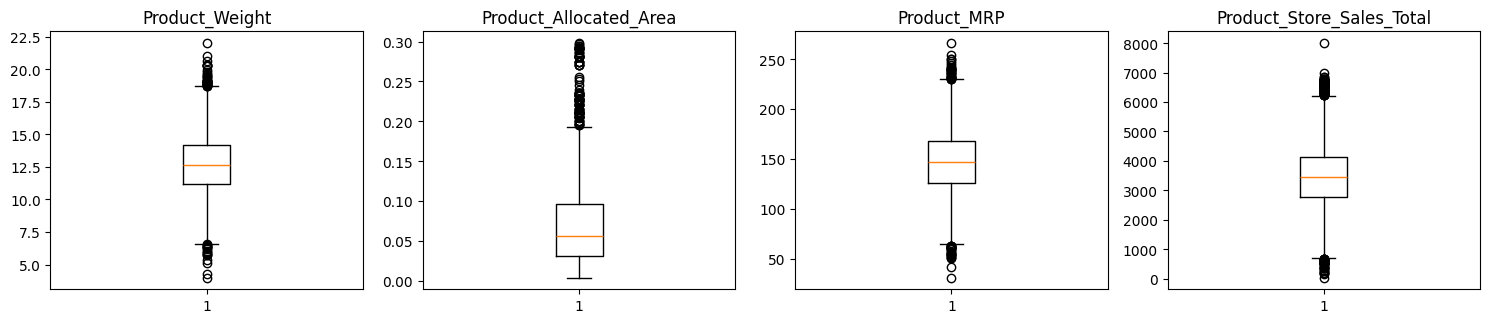

In [76]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## **Data Preparation for Modeling**

- We aim to forecast the Product_Store_Sales_Total.

- Before building the model, we'll drop unnecessary columns and encode the categorical features.

- We'll then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [77]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


Let's remove the columns that are not required.

In [78]:
data = data.drop(["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"], axis=1)

In [79]:
data.shape

(8763, 11)

In [80]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [81]:
# Separating features and the target column
X = data.drop("Product_Store_Sales_Total", axis=1)
y = data["Product_Store_Sales_Total"]

In [82]:
# Splitting the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, shuffle=True
)

In [83]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

### **Data Pre-processing Pipeline**

In [84]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Id_char',
 'Product_Type_Category']

In [85]:
# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Define functions for Model Evaluation

In [86]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built are the following:
1. Random Forest
2. XGBoost

## Random Forest Model

In [87]:
# Define base Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [88]:
# Create pipeline with preprocessing and Random Forest model
rf_pipeline = make_pipeline(preprocessor, rf_model)

In [89]:
# Train the model pipeline on the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

### Checking model performance on training set

In [90]:
rf_estimator_model_train_perf = model_performance_regression(rf_pipeline, X_train,y_train)
print("Training performance \n")
rf_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.988713,468.96547,0.685022,0.684508,0.165673


### Checking model performance on test set

In [91]:
rf_estimator_model_test_perf = model_performance_regression(rf_pipeline, X_test,y_test)
print("Testing performance \n")
rf_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.936833,485.421955,0.668478,0.667211,0.187369


* The training score is more than the test. This is the case of overfitting.

## XGBoost Regressor

In [102]:
# Define base XGBoost model
xgb_model = XGBRegressor(random_state=42)

In [103]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

In [104]:
# Train the model pipeline on the training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

Checking model performance on training set

In [105]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print("Training performance \n")
xgb_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965507,0.685033,0.684519,0.16569


### Checking model performance on test set

In [106]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_pipeline, X_test,y_test)
print("Testing performance \n")
xgb_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429585,0.668482,0.667215,0.187421


* The training score is more than the test. This is the case of overfitting.

# **Model Performance Improvement - Hyperparameter Tuning**

## Hyperparameter Tuning - Random Forest

In [108]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=42)

# Create pipeline with preprocessing and RF model
rf_tuned_pipeline = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = parameters = {
    'randomforestregressor__max_depth':[3, 4, 5, 6],
    'randomforestregressor__max_features': ['sqrt','log2',None],
    'randomforestregressor__n_estimators': [50, 75, 100, 125, 150]
}

# Run the grid search
grid_obj = GridSearchCV(rf_tuned_pipeline, parameters, scoring=r2_score,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=3, max_features='sqrt',
                                       n_estimators=50, random_state=42))])

### Checking model performance on training set

In [109]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance \n")
rf_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,606.360753,481.743126,0.675055,0.674524,0.169374


### Checking model performance on test set

In [110]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance \n")
rf_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,623.165739,495.991042,0.66065,0.659354,0.190983


* The scores for training and test sets are better now than the previous Random Forest Model.

## Hyperparameter Tuning - XGBoost Regressor

In [111]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
xgb_tuned_pipeline = make_pipeline(preprocessor, xgb_tuned)

#Grid of parameters to choose from
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 150, 200],    # number of trees to build
    'xgbregressor___max_depth': [2, 3, 4],    # maximum depth of each tree
    'xgbregressor___colsample_bytree': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor___colsample_bylevel': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor___learning_rate': [0.01, 0.05, 0.1],    # learning rate
    'xgbregressor___reg_lambda': [0.4, 0.5, 0.6],    # L2 regularization factor
}

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned_pipeline, param_grid, scoring=r2_score,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(_colsample_bylevel=0.4, _colsample_bytree=0.4,
                              _...
                              device=None, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, ...))])

### Checking model performance on training set

In [112]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance \n")
xgb_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965511,0.685033,0.684519,0.16569


### Checking model performance on test set

In [113]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance \n")
xgb_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933035,485.429586,0.668482,0.667215,0.187421


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [114]:
# training performance comparison

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
    xgb_estimator_model_train_perf.T,xgb_tuned_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,596.988713,606.360753,596.978222,596.978222
MAE,468.965470,481.743126,468.965507,468.965511
R-squared,0.685022,0.675055,0.685033,0.685033
Adj. R-squared,0.684508,0.674524,0.684519,0.684519
MAPE,0.165673,0.169374,0.165690,0.165690


In [115]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
    xgb_estimator_model_test_perf.T,xgb_tuned_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,615.936833,623.165739,615.933034,615.933035
MAE,485.421955,495.991042,485.429585,485.429586
R-squared,0.668478,0.660650,0.668482,0.668482
Adj. R-squared,0.667211,0.659354,0.667215,0.667215
MAPE,0.187369,0.190983,0.187421,0.187421


In [116]:
(models_train_comp_df - models_test_comp_df).iloc[2]

,R-squared
Random Forest Estimator,0.016545
Random Forest Tuned,0.014405
XGBoost,0.016552
XGBoost Tuned,0.016552


#### Observations:

*   The XGBoost tuned model has a high R2 score.
*   The Random Forest tuned model has the lowest difference between training and test
*   The R2 score of XGBoost tuned is higher so we can consider XGBoost Tuned Model as the best model



## **Model Serialization**

Based on the model comparison, the XGB-tuned model had the best performance on test dataset. We will serialize this model for deployment

In [117]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [118]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/super_kart_sales_prediction_model_v1_0.joblib"

In [119]:
# Save the best trained model pipeline using joblib
joblib.dump(xgb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/super_kart_sales_prediction_model_v1_0.joblib


In [120]:
# Load the saved model pipeline from the file
saved_model = joblib.load("backend_files/super_kart_sales_prediction_model_v1_0.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [121]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(_colsample_bylevel=0.4, _colsample_bytree=0.4,
                              _...
                              device=None, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, ...))])

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [122]:
saved_model.predict(X_test)

array([3298.6277, 4870.268 , 4836.3696, ..., 3317.8027, 3298.6277,
       3298.6277], dtype=float32)

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Flask Web Framework


## Dependencies File

## Dockerfile

## Setting up a Hugging Face Docker Space for the Backend

## Uploading Files to Hugging Face Space (Docker Space)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

## Dependencies File

## DockerFile

In [30]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


FileNotFoundError: [Errno 2] No such file or directory: 'frontend_files/Dockerfile'

## Uploading Files to Hugging Face Space (Streamlit Space)

# **Actionable Insights and Business Recommendations**

-

-